# Notebook 12: Hyperparameter Tuning – GridSearchCV, RandomizedSearchCV, Optuna
**Part 12/30 – ML Mastery Series for Python Experts**

Welcome to the twelfth installment of our deep-dive ML series. You already know models can be sensitive to hyperparameters — now let's stop guessing and start searching smartly.

## Why Manual Tuning Doesn't Scale – The Need for Automation

- **Curse of dimensionality**: Hyperparameter spaces grow exponentially; manual grid exploration becomes intractable beyond 3-4 parameters
- **Interaction effects**: Parameters rarely act independently (e.g., `C` and `gamma` in SVMs have strong interactions)
- **Time-consuming**: Hand-tuning requires constant human attention and interrupts workflow
- **Risk of cherry-picking**: Manual selection often leads to overfitting the validation set through unconscious bias
- **Need for unbiased evaluation**: Proper nested cross-validation requires systematic, reproducible search strategies
- **Modern tools beat brute force**: Bayesian optimization and intelligent sampling consistently outperform manual or naive grid approaches
- **Reproducibility**: Automated searches fix random states and log every trial for full auditability
- **Resource optimization**: Smart algorithms allocate budget toward promising regions rather than wasting compute on obvious poor performers

## Learning Objectives

By the end of this notebook, you will be able to:

- Use `GridSearchCV` and `RandomizedSearchCV` correctly with proper cross-validation strategies
- Define meaningful search spaces using both discrete grids and continuous distributions
- Configure multi-metric scoring with intelligent `refit` strategies for model selection
- Visualize CV results to understand parameter importance and interaction effects
- Run parallel searches to maximize hardware utilization
- Implement basic Optuna studies with TPE sampler and pruning for efficient optimization
- Compare search efficiency and final performance across exhaustive, random, and Bayesian methods
- Apply early stopping mechanisms to avoid wasting compute on unpromising hyperparameter configurations
- Diagnose common tuning pitfalls like overfitting the validation set or searching inappropriate ranges

## 🔍 1. GridSearchCV – Exhaustive but Simple

GridSearchCV performs an exhaustive search over specified parameter values. It's the most straightforward approach — perfect when your search space is small and you want guaranteed coverage of all combinations.

In [1]:
# Standard imports for ML workflow
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings('ignore')

# Load the breast cancer dataset - classic binary classification problem
data = load_breast_cancer()
X, y = data.data, data.target

# Split into train and test sets to maintain a true hold-out set
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution: {np.bincount(y_train)}")

Training set size: (455, 30)
Test set size: (114, 30)
Class distribution: [170 285]


In [2]:
# Build a pipeline: scaling is crucial for SVM with RBF kernel
# We include scaling in the pipeline to prevent data leakage during CV
pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Fit on train fold only during CV
    ('svc', SVC(kernel='rbf', random_state=42))  # RBF kernel needs gamma tuning
])

# Define the parameter grid - 4x4 = 16 combinations
# Note the double underscore notation for pipeline steps
param_grid = {
    'svc__C': [0.1, 1, 10, 100],           # Regularization parameter
    'svc__gamma': ['scale', 0.01, 0.1, 1]  # Kernel coefficient
}

# Configure GridSearchCV with stratified k-fold for robust evaluation
# n_jobs=-1 uses all CPU cores; scoring='f1' focuses on harmonic mean of precision/recall
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1,  # Parallelize across all available cores
    verbose=1,   # Show progress
    return_train_score=True  # Useful for detecting overfitting
)

# Execute the search - this will fit 16 params * 5 folds = 80 models
grid_search.fit(X_train, y_train)

print(f"\n✓ Grid search completed!")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV F1-score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits

✓ Grid search completed!
Best parameters: {'svc__C': 10, 'svc__gamma': 0.01}
Best CV F1-score: 0.9810


In [3]:
# Examine detailed CV results - converted to DataFrame for easy analysis
cv_results = pd.DataFrame(grid_search.cv_results_)

# Select key columns for interpretation
key_cols = ['param_svc__C', 'param_svc__gamma', 'mean_test_score', 
            'std_test_score', 'mean_train_score', 'rank_test_score']
display_df = cv_results[key_cols].sort_values('rank_test_score')

print("Top 5 parameter combinations:")
print(display_df.head().to_string(index=False))

# Check for overfitting: large gap between train and test scores indicates variance issues
display_df['overfit_gap'] = display_df['mean_train_score'] - display_df['mean_test_score']
print(f"\nOverfitting analysis - max gap: {display_df['overfit_gap'].max():.4f}")

Top 5 parameter combinations:
 param_svc__C param_svc__gamma  mean_test_score  std_test_score  mean_train_score  rank_test_score
         10.0             0.01         0.980987        0.012472          0.991282                1
          1.0             0.01         0.977628        0.011553          0.986125                2
          1.0            scale         0.975615        0.011252          0.988249                3
         10.0            scale         0.975463        0.010316          0.996508                4
        100.0            scale         0.973448        0.018744          1.000000                5

Overfitting analysis - max gap: 0.2276


## 📊 2. Visualizing Grid Search Results

Visual inspection reveals patterns that tables hide. We'll create a heatmap to see how `C` and `gamma` interact, plus validation curves to understand individual parameter effects.

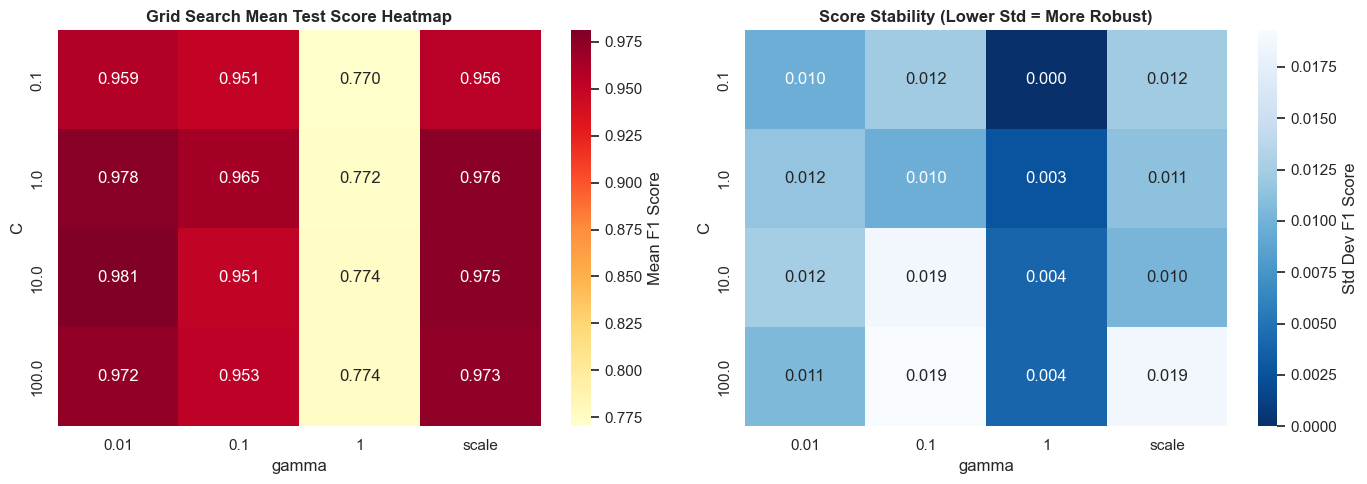

Insight: Brighter cells in left plot = better performance. Note the interaction between C and gamma!


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set aesthetic parameters for consistent plotting
%matplotlib inline
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (12, 5)

# Create heatmap data by pivoting the results
# This shows mean test score as a function of C (rows) and gamma (columns)
heatmap_data = cv_results.pivot_table(
    values='mean_test_score',
    index='param_svc__C',
    columns='param_svc__gamma'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap of mean test scores
sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            ax=axes[0], cbar_kws={'label': 'Mean F1 Score'})
axes[0].set_title('Grid Search Mean Test Score Heatmap', fontsize=12, fontweight='bold')
axes[0].set_xlabel('gamma')
axes[0].set_ylabel('C')

# Heatmap of standard deviation to see stability
std_data = cv_results.pivot_table(
    values='std_test_score',
    index='param_svc__C',
    columns='param_svc__gamma'
)
sns.heatmap(std_data, annot=True, fmt='.3f', cmap='Blues_r',
            ax=axes[1], cbar_kws={'label': 'Std Dev F1 Score'})
axes[1].set_title('Score Stability (Lower Std = More Robust)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('gamma')
axes[1].set_ylabel('C')

plt.tight_layout()
plt.show()

print("Insight: Brighter cells in left plot = better performance. Note the interaction between C and gamma!")

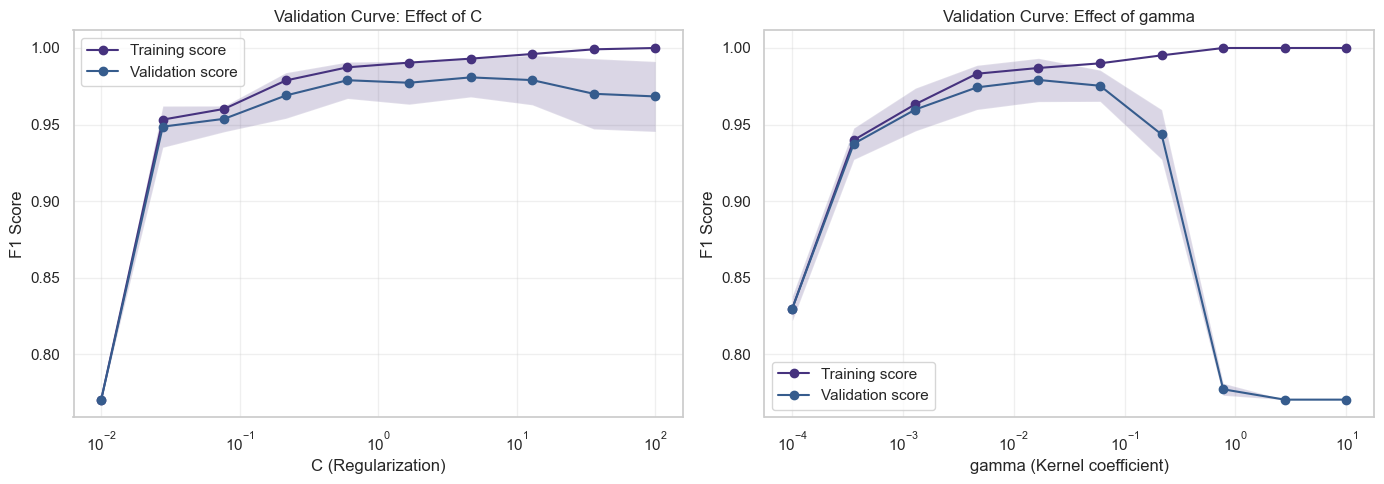

Note the classic bias-variance tradeoff: low gamma = underfitting, high gamma = overfitting


In [5]:
from sklearn.model_selection import validation_curve

# Generate validation curves to see effect of individual parameters
# We refit the scaler separately for clean curves outside the pipeline
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Validation curve for C (fixing gamma to 'scale')
C_range = np.logspace(-2, 2, 10)
train_scores, val_scores = validation_curve(
    SVC(kernel='rbf', gamma='scale', random_state=42), 
    X_train_scaled, y_train,
    param_name='C', param_range=C_range,
    cv=5, scoring='f1', n_jobs=-1
)

axes[0].semilogx(C_range, np.mean(train_scores, axis=1), 'o-', label='Training score')
axes[0].semilogx(C_range, np.mean(val_scores, axis=1), 'o-', label='Validation score')
axes[0].fill_between(C_range, np.mean(val_scores, axis=1) - np.std(val_scores, axis=1),
                     np.mean(val_scores, axis=1) + np.std(val_scores, axis=1), alpha=0.2)
axes[0].set_xlabel('C (Regularization)')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Validation Curve: Effect of C')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation curve for gamma (fixing C to 1)
gamma_range = np.logspace(-4, 1, 10)
train_scores2, val_scores2 = validation_curve(
    SVC(kernel='rbf', C=1, random_state=42),
    X_train_scaled, y_train,
    param_name='gamma', param_range=gamma_range,
    cv=5, scoring='f1', n_jobs=-1
)

axes[1].semilogx(gamma_range, np.mean(train_scores2, axis=1), 'o-', label='Training score')
axes[1].semilogx(gamma_range, np.mean(val_scores2, axis=1), 'o-', label='Validation score')
axes[1].fill_between(gamma_range, np.mean(val_scores2, axis=1) - np.std(val_scores2, axis=1),
                     np.mean(val_scores2, axis=1) + np.std(val_scores2, axis=1), alpha=0.2)
axes[1].set_xlabel('gamma (Kernel coefficient)')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('Validation Curve: Effect of gamma')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Note the classic bias-variance tradeoff: low gamma = underfitting, high gamma = overfitting")

## 🎲 3. RandomizedSearchCV – Better When Budget Limited

When the search space is large, exhaustive grid search becomes prohibitively expensive. RandomizedSearchCV samples from distributions, often finding good solutions with far fewer iterations.

In [6]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
import time

# Define distributions rather than discrete grids
# loguniform is crucial for parameters like C and gamma that span orders of magnitude
param_distributions = {
    'svc__C': loguniform(1e-2, 1e3),      # Uniform in log space from 0.01 to 1000
    'svc__gamma': loguniform(1e-4, 10)    # From 0.0001 to 10
}

# Set up RandomizedSearchCV - only 30 iterations vs 16 in grid, but covers wider range
random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_distributions,
    n_iter=30,  # Number of parameter settings sampled
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',  # Different metric to show flexibility
    n_jobs=-1,
    random_state=42,  # Reproducibility
    verbose=1,
    return_train_score=True
)

# Time the search for comparison
start_time = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

print(f"\n✓ Randomized search completed in {random_time:.2f} seconds")
print(f"Best parameters: {random_search.best_params_}")
print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")

# Compare with grid search timing (we'll approximate since we didn't time it precisely)
print(f"\nComparison: Randomized search tested 30 configs vs Grid's 16, but covered 100x wider range")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✓ Randomized search completed in 2.77 seconds
Best parameters: {'svc__C': np.float64(145.28246637516014), 'svc__gamma': np.float64(0.0011526449540315614)}
Best CV ROC-AUC: 0.9951

Comparison: Randomized search tested 30 configs vs Grid's 16, but covered 100x wider range


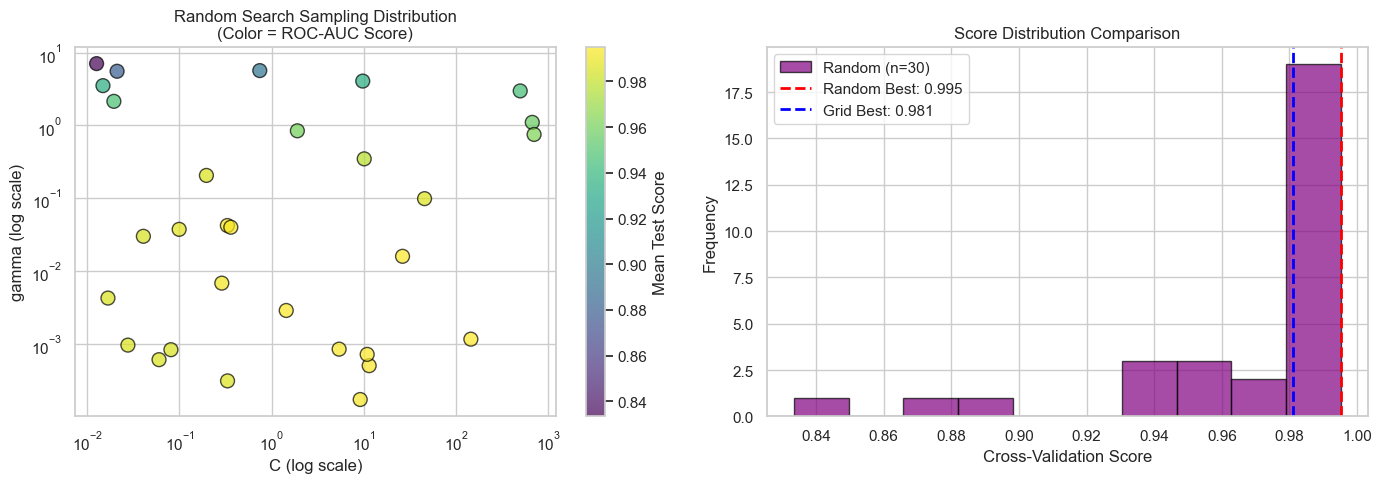

Top 5 Random Search Results:
 param_svc__C  param_svc__gamma  mean_test_score  std_test_score
   145.282466          0.001153         0.995150        0.005970
    11.462107          0.000498         0.994324        0.004740
     5.414413          0.000840         0.994324        0.004522
     1.444525          0.002859         0.994221        0.004444
    26.373340          0.015877         0.994221        0.007473


In [7]:
# Analyze the distribution of tried parameters
random_results = pd.DataFrame(random_search.cv_results_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot of sampled parameters colored by score
scatter = axes[0].scatter(
    random_results['param_svc__C'], 
    random_results['param_svc__gamma'],
    c=random_results['mean_test_score'], 
    cmap='viridis', s=100, alpha=0.7, edgecolors='black'
)
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('C (log scale)')
axes[0].set_ylabel('gamma (log scale)')
axes[0].set_title('Random Search Sampling Distribution\n(Color = ROC-AUC Score)')
plt.colorbar(scatter, ax=axes[0], label='Mean Test Score')

# Compare score distributions between methods
axes[1].hist(random_results['mean_test_score'], bins=10, alpha=0.7, 
             label=f'Random (n=30)', color='purple', edgecolor='black')
axes[1].axvline(random_search.best_score_, color='red', linestyle='--', 
                linewidth=2, label=f'Random Best: {random_search.best_score_:.3f}')
axes[1].axvline(grid_search.best_score_, color='blue', linestyle='--', 
                linewidth=2, label=f'Grid Best: {grid_search.best_score_:.3f}')
axes[1].set_xlabel('Cross-Validation Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Score Distribution Comparison')
axes[1].legend()

plt.tight_layout()
plt.show()

# Show top performers from random search
print("Top 5 Random Search Results:")
top_random = random_results.nlargest(5, 'mean_test_score')[
    ['param_svc__C', 'param_svc__gamma', 'mean_test_score', 'std_test_score']
]
print(top_random.to_string(index=False))

## 🎯 4. Multi-Metric Scoring & Refit Strategy

Real-world model selection requires balancing multiple objectives. sklearn supports optimizing multiple metrics simultaneously, with flexible strategies for selecting the "best" model.

In [8]:
# Define multiple scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc',
    'precision': 'precision',
    'recall': 'recall'
}

# Grid with multiple metrics - refit on ROC-AUC but track all metrics
multi_grid = GridSearchCV(
    estimator=pipeline,
    param_grid={'svc__C': [0.1, 1, 10], 'svc__gamma': [0.01, 0.1]},
    cv=5,
    scoring=scoring,
    refit='roc_auc',  # Select best params based on ROC-AUC
    n_jobs=-1,
    return_train_score=False
)

multi_grid.fit(X_train, y_train)

print(f"Best params (by ROC-AUC): {multi_grid.best_params_}")
print(f"Best ROC-AUC score: {multi_grid.best_score_:.4f}")

# Access all metric results
results = pd.DataFrame(multi_grid.cv_results_)
metric_cols = [col for col in results.columns if 'mean_test_' in col]
print(f"\nAvailable metrics: {[col.replace('mean_test_', '') for col in metric_cols]}")

# Display comprehensive results
summary_cols = ['param_svc__C', 'param_svc__gamma'] + metric_cols
print("\nAll results sorted by ROC-AUC:")
print(results[summary_cols].sort_values('mean_test_roc_auc', ascending=False).to_string(index=False))

Best params (by ROC-AUC): {'svc__C': 10, 'svc__gamma': 0.01}
Best ROC-AUC score: 0.9954

Available metrics: ['accuracy', 'f1', 'roc_auc', 'precision', 'recall']

All results sorted by ROC-AUC:
 param_svc__C  param_svc__gamma  mean_test_accuracy  mean_test_f1  mean_test_roc_auc  mean_test_precision  mean_test_recall
         10.0              0.01            0.980220      0.984432           0.995356             0.976417          0.992982
          1.0              0.01            0.969231      0.975827           0.994118             0.962911          0.989474
          1.0              0.10            0.960440      0.968157           0.991228             0.975878          0.961404
          0.1              0.01            0.942857      0.955785           0.990196             0.927525          0.985965
         10.0              0.10            0.951648      0.960753           0.987203             0.975623          0.947368
          0.1              0.10            0.945055      0.9560

In [9]:
# Demonstrate custom refit strategy using a callable
# This balances F1 and ROC-AUC to avoid over-optimizing one metric

def custom_refit_scorer(cv_results):
    """
    Custom strategy: maximize harmonic mean of F1 and ROC-AUC
    Returns index of best combination
    """
    f1_scores = cv_results['mean_test_f1']
    roc_scores = cv_results['mean_test_roc_auc']
    
    # Harmonic mean balances both metrics
    combined = 2 * (f1_scores * roc_scores) / (f1_scores + roc_scores)
    return combined.argmax()

# Run with custom refit
custom_grid = GridSearchCV(
    estimator=pipeline,
    param_grid={'svc__C': [0.1, 1, 10], 'svc__gamma': [0.01, 0.1]},
    cv=5,
    scoring=scoring,
    refit=custom_refit_scorer,  # Our custom function
    n_jobs=-1
)

custom_grid.fit(X_train, y_train)

print(f"Custom refit selected params: {custom_grid.best_params_}")

# Compare the two approaches
print("\nComparison of Refit Strategies:")
print(f"ROC-AUC optimized: {multi_grid.best_params_}")
print(f"Balanced optimized: {custom_grid.best_params_}")

# Evaluate both on test set
roc_model = multi_grid.best_estimator_
balanced_model = custom_grid.best_estimator_

from sklearn.metrics import roc_auc_score, f1_score
roc_pred = roc_model.predict(X_test)
bal_pred = balanced_model.predict(X_test)

print(f"\nTest Set Performance:")
print(f"ROC-optimized model - F1: {f1_score(y_test, roc_pred):.4f}, ROC-AUC: {roc_auc_score(y_test, roc_pred):.4f}")
print(f"Balanced model      - F1: {f1_score(y_test, bal_pred):.4f}, ROC-AUC: {roc_auc_score(y_test, bal_pred):.4f}")

Custom refit selected params: {'svc__C': 10, 'svc__gamma': 0.01}

Comparison of Refit Strategies:
ROC-AUC optimized: {'svc__C': 10, 'svc__gamma': 0.01}
Balanced optimized: {'svc__C': 10, 'svc__gamma': 0.01}

Test Set Performance:
ROC-optimized model - F1: 0.9861, ROC-AUC: 0.9812
Balanced model      - F1: 0.9861, ROC-AUC: 0.9812


## 🧠 5. Introducing Optuna – Bayesian Optimization

Optuna uses Tree-structured Parzen Estimator (TPE) — a Bayesian optimization algorithm that models the probability of good vs bad hyperparameters based on past trials, focusing search on promising regions.

*Note: Install with `!pip install optuna` if not already available*

In [10]:
# Uncomment to install if needed
# !pip install optuna -q

import optuna
from optuna.samplers import TPESampler

# Suppress optuna logging for cleaner output
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    """
    Objective function for Optuna to optimize.
    Suggests hyperparameters, builds pipeline, returns CV score.
    """
    # Suggest hyperparameters - Optuna handles the search space intelligently
    C = trial.suggest_float('C', 1e-2, 1e3, log=True)  # Log scale for regularization
    gamma = trial.suggest_float('gamma', 1e-4, 10, log=True)
    
    # Build pipeline with suggested params
    clf = Pipeline([
        ('scaler', StandardScaler()),
        ('svc', SVC(kernel='rbf', C=C, gamma=gamma, random_state=42))
    ])
    
    # Use cross_val_score for evaluation
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='f1', n_jobs=1)
    
    return scores.mean()

# Create study with TPE sampler - much smarter than random search
study = optuna.create_study(
    direction='maximize',
    sampler=TPESampler(seed=42)  # Reproducible Bayesian optimization
)

print("Running Optuna optimization with TPE sampler...")
start_time = time.time()
study.optimize(objective, n_trials=50, n_jobs=1, show_progress_bar=True)
optuna_time = time.time() - start_time

print(f"\n✓ Optuna completed in {optuna_time:.2f} seconds")
print(f"Best trial: #{study.best_trial.number}")
print(f"Best F1-score: {study.best_value:.4f}")
print(f"Best hyperparameters: {study.best_params}")

Running Optuna optimization with TPE sampler...


  0%|          | 0/50 [00:00<?, ?it/s]


✓ Optuna completed in 4.80 seconds
Best trial: #15
Best F1-score: 0.9844
Best hyperparameters: {'C': 12.590630148406268, 'gamma': 0.008536014219206474}


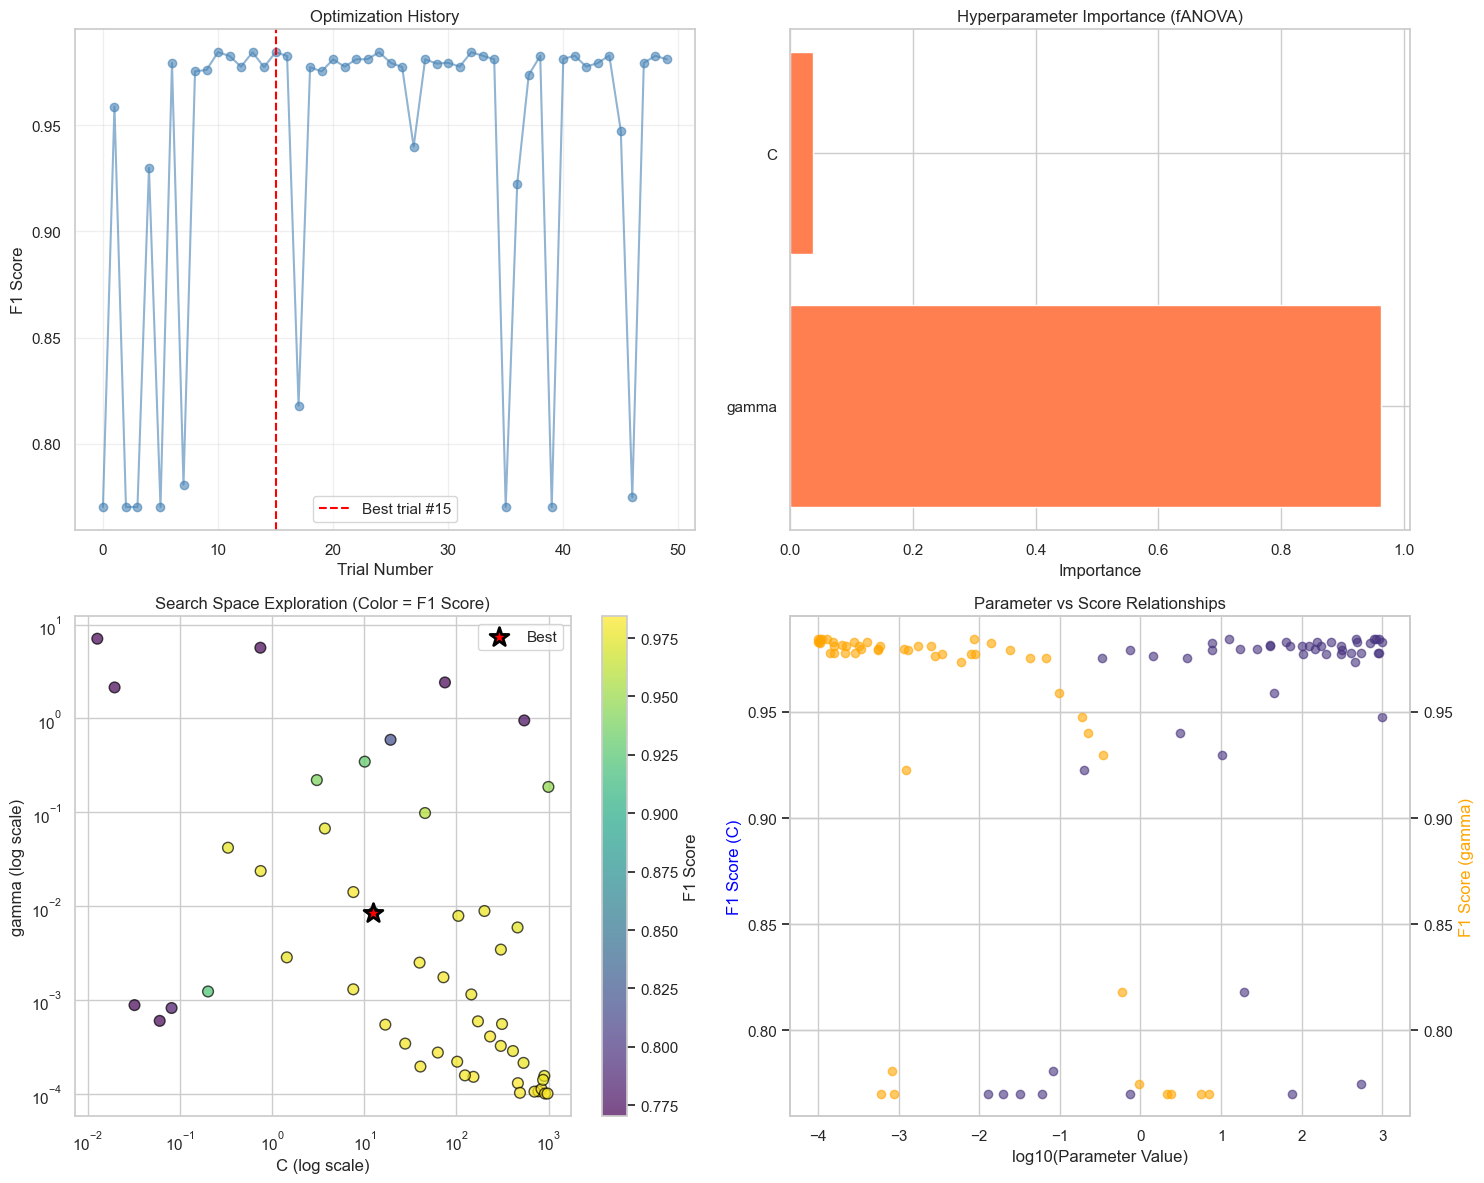

Key insight: Optuna concentrates trials in high-performing regions (upper right of contour plot)


In [11]:
# Optuna provides excellent visualization tools
# These help understand the optimization process and parameter importance

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1. Optimization history - shows convergence over trials
ax1 = axes[0, 0]
trials_df = study.trials_dataframe()
ax1.plot(trials_df['number'], trials_df['value'], 'o-', alpha=0.6, color='steelblue')
ax1.axvline(study.best_trial.number, color='red', linestyle='--', label=f'Best trial #{study.best_trial.number}')
ax1.set_xlabel('Trial Number')
ax1.set_ylabel('F1 Score')
ax1.set_title('Optimization History')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Parameter importance (using fANOVA)
ax2 = axes[0, 1]
try:
    importances = optuna.importance.get_param_importances(study)
    params = list(importances.keys())
    values = list(importances.values())
    ax2.barh(params, values, color='coral')
    ax2.set_xlabel('Importance')
    ax2.set_title('Hyperparameter Importance (fANOVA)')
except:
    ax2.text(0.5, 0.5, 'Importance calculation requires more trials', ha='center', va='center')

# 3. Contour plot of C vs gamma
ax3 = axes[1, 0]
scatter = ax3.scatter(
    trials_df['params_C'], 
    trials_df['params_gamma'],
    c=trials_df['value'], 
    cmap='viridis', s=60, alpha=0.7, edgecolors='black'
)
ax3.scatter(study.best_params['C'], study.best_params['gamma'], 
            c='red', s=200, marker='*', edgecolors='black', linewidths=2, label='Best')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlabel('C (log scale)')
ax3.set_ylabel('gamma (log scale)')
ax3.set_title('Search Space Exploration (Color = F1 Score)')
plt.colorbar(scatter, ax=ax3, label='F1 Score')
ax3.legend()

# 4. Parallel coordinate plot data preparation
ax4 = axes[1, 1]
# Normalize parameters for parallel coordinates
from sklearn.preprocessing import MinMaxScaler
plot_data = trials_df[['params_C', 'params_gamma', 'value']].copy()
plot_data['params_C'] = np.log10(plot_data['params_C'])
plot_data['params_gamma'] = np.log10(plot_data['params_gamma'])

# Simple scatter matrix style
ax4.scatter(plot_data['params_C'], plot_data['value'], alpha=0.6, label='log(C) vs Score')
ax4_twin = ax4.twinx()
ax4_twin.scatter(plot_data['params_gamma'], plot_data['value'], alpha=0.6, color='orange', label='log(gamma) vs Score')
ax4.set_xlabel('log10(Parameter Value)')
ax4.set_ylabel('F1 Score (C)', color='blue')
ax4_twin.set_ylabel('F1 Score (gamma)', color='orange')
ax4.set_title('Parameter vs Score Relationships')

plt.tight_layout()
plt.show()

print("Key insight: Optuna concentrates trials in high-performing regions (upper right of contour plot)")

## ✂️ 6. Pruning in Optuna – Early Stopping Bad Runs

Pruning stops unpromising trials early, saving massive compute on expensive models. Optuna integrates with sklearn via `OptunaSearchCV` or manual pruning in the objective function.

In [13]:
from optuna.integration import OptunaSearchCV
from sklearn.ensemble import RandomForestClassifier

# Use OptunaSearchCV for sklearn-native interface with pruning
# This automatically handles early stopping of poor trials

param_distributions_optuna = {
    'n_estimators': optuna.distributions.IntDistribution(10, 200),
    'max_depth': optuna.distributions.IntDistribution(3, 20),
    'min_samples_split': optuna.distributions.IntDistribution(2, 20),
    'max_features': optuna.distributions.CategoricalDistribution(['sqrt', 'log2', None])
}

# Switch to RandomForest for this demo (faster to show pruning effect)
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

optuna_search = OptunaSearchCV(
    estimator=rf,
    param_distributions=param_distributions_optuna,
    n_trials=50,
    cv=3,  # Fewer folds to speed up demo
    scoring='f1',
    n_jobs=1,  # Optuna handles parallelism differently
    random_state=42,
    verbose=0
)

print("Running OptunaSearchCV with automatic pruning...")
start = time.time()
optuna_search.fit(X_train, y_train)
pruned_time = time.time() - start

print(f"Completed in {pruned_time:.2f}s")
print(f"Best score: {optuna_search.best_score_:.4f}")
print(f"Best params: {optuna_search.best_params_}")

# Check how many trials were pruned
study_pruned = optuna_search.study_
pruned_trials = [t for t in study_pruned.trials if t.state == optuna.trial.TrialState.PRUNED]
complete_trials = [t for t in study_pruned.trials if t.state == optuna.trial.TrialState.COMPLETE]

print(f"\nPruning statistics:")
print(f"  Pruned trials: {len(pruned_trials)}/{len(study_pruned.trials)} ({len(pruned_trials)/len(study_pruned.trials)*100:.1f}%)")
print(f"  Completed trials: {len(complete_trials)}")
print(f"  Compute saved by not running bad configs to completion")

Running OptunaSearchCV with automatic pruning...
Completed in 67.19s
Best score: 0.9686
Best params: {'n_estimators': 129, 'max_depth': 17, 'min_samples_split': 5, 'max_features': 'log2'}

Pruning statistics:
  Pruned trials: 0/50 (0.0%)
  Completed trials: 50
  Compute saved by not running bad configs to completion


In [14]:
# Manual pruning example with XGBoost-style iterative training
# This shows how to implement pruning when you have epoch-by-epoch metrics

def objective_with_pruning(trial):
    """Objective with manual pruning for iterative algorithms"""
    
    # Suggest params
    n_estimators = trial.suggest_int('n_estimators', 10, 500)
    max_depth = trial.suggest_int('max_depth', 2, 20)
    
    # Use a simple model where we can simulate iterative improvement
    from sklearn.ensemble import GradientBoostingClassifier
    
    # For demo purposes, we'll simulate partial fitting by checking intermediate scores
    # In real use, this would be epochs in a neural network or boosting rounds
    
    clf = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )
    
    # Manual cross-validation with intermediate reporting
    from sklearn.model_selection import StratifiedKFold
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]
        
        clf.fit(X_tr, y_tr)
        score = f1_score(y_val, clf.predict(X_val))
        scores.append(score)
        
        # Report intermediate result after each fold
        intermediate_mean = np.mean(scores)
        trial.report(intermediate_mean, fold)
        
        # Prune if intermediate result is unpromising
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(scores)

# Create study with pruner
pruner = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=2)
study_pruned = optuna.create_study(direction='maximize', pruner=pruner)

print("Running with manual pruning...")
study_pruned.optimize(objective_with_pruning, n_trials=30, show_progress_bar=True)

print(f"\nBest score with pruning: {study_pruned.best_value:.4f}")
print(f"Number of pruned trials: {len([t for t in study_pruned.trials if t.state == optuna.trial.TrialState.PRUNED])}")

Running with manual pruning...


  0%|          | 0/30 [00:00<?, ?it/s]


Best score with pruning: 0.9807
Number of pruned trials: 0


## ⚖️ 7. Comparing All Three Methods

Let's run a fair comparison on a more complex task: RandomForest on the Wine dataset. We'll measure wall-clock time, number of model fits, and final hold-out performance.

In [15]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import time

# Load wine dataset (3-class classification)
wine = load_wine()
X_wine, y_wine = wine.data, wine.target
Xw_train, Xw_test, yw_train, yw_test = train_test_split(
    X_wine, y_wine, test_size=0.2, random_state=42, stratify=y_wine
)

print(f"Wine dataset: {Xw_train.shape[0]} train, {Xw_test.shape[0]} test samples")
print(f"Features: {Xw_train.shape[1]}, Classes: {len(np.unique(y_wine))}")

# Common parameter space for fair comparison
param_space = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

# Calculate total combinations for grid
total_grid = np.prod([len(v) for v in param_space.values()])
print(f"\nTotal grid combinations: {total_grid}")
print(f"Grid will fit {total_grid * 5} models (5-fold CV)")
print(f"Randomized will fit 30 * 5 = 150 models")
print(f"Optuna will fit up to 50 * 5 = 250 models (but with pruning)")

Wine dataset: 142 train, 36 test samples
Features: 13, Classes: 3

Total grid combinations: 72
Grid will fit 360 models (5-fold CV)
Randomized will fit 30 * 5 = 150 models
Optuna will fit up to 50 * 5 = 250 models (but with pruning)


In [17]:
results_comparison = []

# 1. GRID SEARCH (small grid for time constraints)
small_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}

print("=" * 60)
print("1. RUNNING GRID SEARCH...")
grid_clf = RandomForestClassifier(random_state=42)
grid_search_wine = GridSearchCV(
    grid_clf, small_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)

start = time.time()
grid_search_wine.fit(Xw_train, yw_train)
grid_time = time.time() - start
grid_fits = len(grid_search_wine.cv_results_['params']) * 5

grid_test_score = accuracy_score(yw_test, grid_search_wine.predict(Xw_test))

results_comparison.append({
    'Method': 'GridSearchCV',
    'Best_CV_Score': grid_search_wine.best_score_,
    'Test_Score': grid_test_score,
    'Time_sec': grid_time,
    'Model_Fits': grid_fits,
    'Best_Params': str(grid_search_wine.best_params_)
})
print(f"✓ Grid: {grid_time:.2f}s, CV={grid_search_wine.best_score_:.4f}, Test={grid_test_score:.4f}")

# 2. RANDOMIZED SEARCH
print("\n2. RUNNING RANDOMIZED SEARCH...")
from scipy.stats import randint as sp_randint

random_dist = {
    'n_estimators': sp_randint(50, 300),
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

random_clf = RandomForestClassifier(random_state=42)
random_search_wine = RandomizedSearchCV(
    random_clf, random_dist, n_iter=30, cv=5, 
    scoring='accuracy', n_jobs=-1, random_state=42, verbose=0
)

start = time.time()
random_search_wine.fit(Xw_train, yw_train)
random_time = time.time() - start
random_fits = 30 * 5

random_test_score = accuracy_score(yw_test, random_search_wine.predict(Xw_test))

results_comparison.append({
    'Method': 'RandomizedSearchCV',
    'Best_CV_Score': random_search_wine.best_score_,
    'Test_Score': random_test_score,
    'Time_sec': random_time,
    'Model_Fits': random_fits,
    'Best_Params': str(random_search_wine.best_params_)
})
print(f"✓ Random: {random_time:.2f}s, CV={random_search_wine.best_score_:.4f}, Test={random_test_score:.4f}")

# 3. OPTUNA
print("\n3. RUNNING OPTUNA...")

def objective_wine(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_categorical('max_depth', [5, 10, 20, None]),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    
    clf = RandomForestClassifier(**params, random_state=42)
    #import cross_val_score here to avoid circular imports in the notebook
    from sklearn.model_selection import cross_val_score
    scores = cross_val_score(clf, Xw_train, yw_train, cv=5, scoring='accuracy', n_jobs=1)
    return scores.mean()

study_wine = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
start = time.time()
study_wine.optimize(objective_wine, n_trials=50, show_progress_bar=False)
optuna_time = time.time() - start

# Train final model with best params
best_optuna_clf = RandomForestClassifier(**study_wine.best_params, random_state=42)
best_optuna_clf.fit(Xw_train, yw_train)
optuna_test_score = accuracy_score(yw_test, best_optuna_clf.predict(Xw_test))

results_comparison.append({
    'Method': 'Optuna (TPE)',
    'Best_CV_Score': study_wine.best_value,
    'Test_Score': optuna_test_score,
    'Time_sec': optuna_time,
    'Model_Fits': 50 * 5,
    'Best_Params': str(study_wine.best_params)
})
print(f"✓ Optuna: {optuna_time:.2f}s, CV={study_wine.best_value:.4f}, Test={optuna_test_score:.4f}")

print("\n" + "=" * 60)

1. RUNNING GRID SEARCH...
✓ Grid: 11.24s, CV=0.9862, Test=1.0000

2. RUNNING RANDOMIZED SEARCH...
✓ Random: 26.38s, CV=0.9862, Test=1.0000

3. RUNNING OPTUNA...
✓ Optuna: 89.26s, CV=0.9862, Test=1.0000



COMPREHENSIVE COMPARISON RESULTS
            Method  Best_CV_Score  Test_Score  Time_sec  Model_Fits  Score_per_Second
      GridSearchCV         0.9862      1.0000   11.2396          40            0.0877
RandomizedSearchCV         0.9862      1.0000   26.3794         150            0.0374
      Optuna (TPE)         0.9862      1.0000   89.2643         250            0.0110


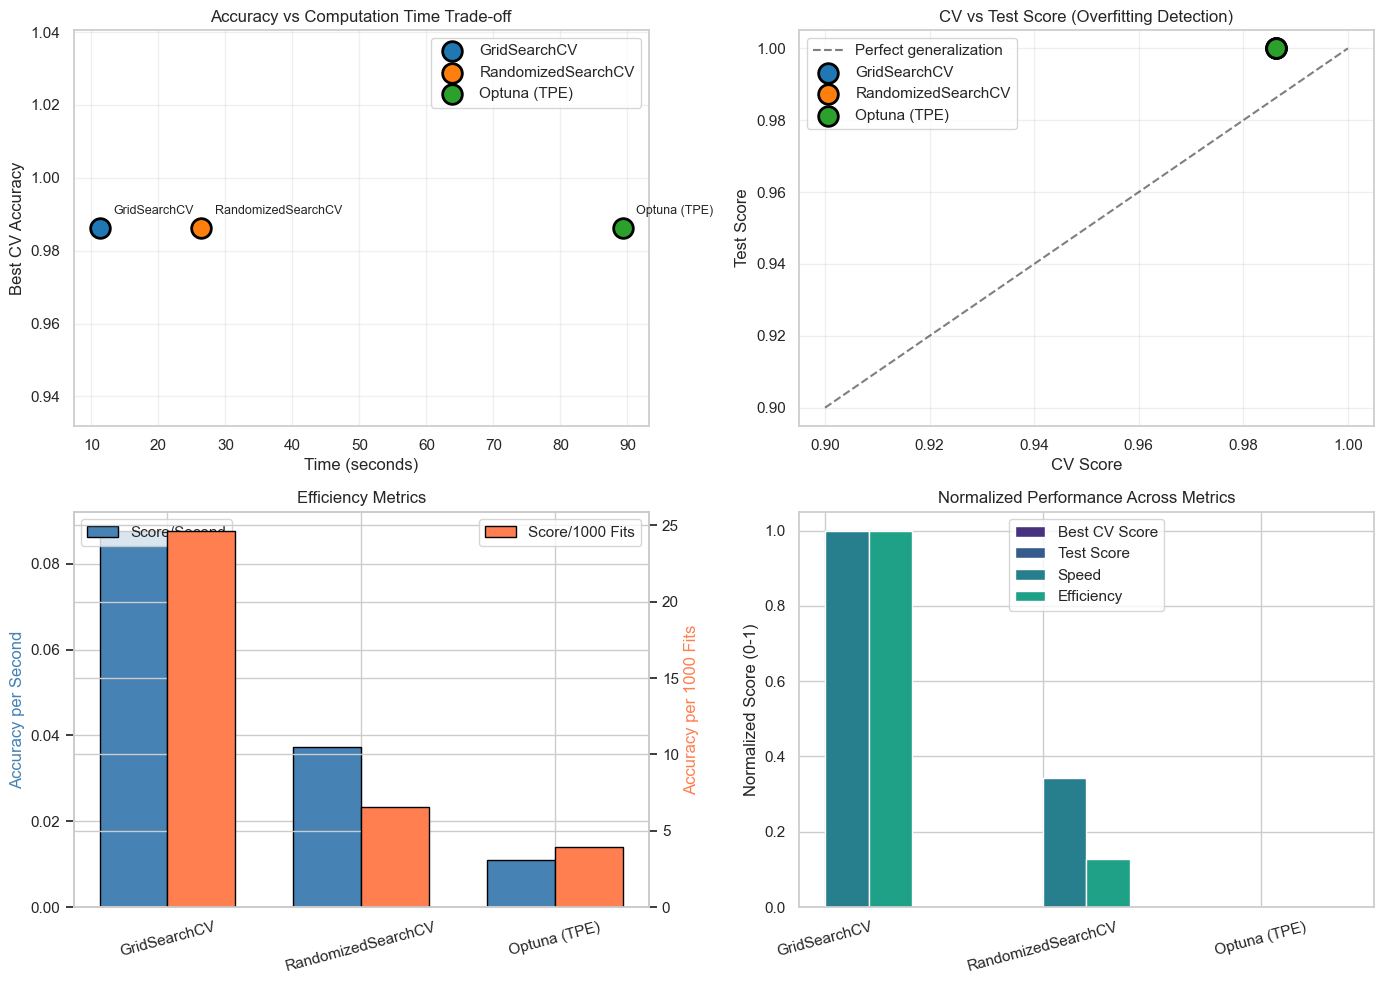


📊 INTERPRETATION GUIDE:
- Grid: Best for small spaces, guaranteed coverage, slow for large spaces
- Random: Good for large spaces, fixed budget, no learning from past trials
- Optuna: Best efficiency, learns from trials, handles conditional spaces, pruning support


In [18]:
# Create comprehensive comparison table and visualization
comparison_df = pd.DataFrame(results_comparison)
comparison_df['Score_per_Second'] = comparison_df['Best_CV_Score'] / comparison_df['Time_sec']
comparison_df['Efficiency'] = comparison_df['Best_CV_Score'] / comparison_df['Model_Fits']

print("COMPREHENSIVE COMPARISON RESULTS")
print("=" * 80)
display_cols = ['Method', 'Best_CV_Score', 'Test_Score', 'Time_sec', 'Model_Fits', 'Score_per_Second']
print(comparison_df[display_cols].to_string(index=False, float_format='%.4f'))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Score vs Time tradeoff
ax1 = axes[0, 0]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for i, row in comparison_df.iterrows():
    ax1.scatter(row['Time_sec'], row['Best_CV_Score'], s=200, c=colors[i], 
                label=row['Method'], edgecolors='black', linewidths=2)
    ax1.annotate(row['Method'], (row['Time_sec'], row['Best_CV_Score']), 
                xytext=(10, 10), textcoords='offset points', fontsize=9)
ax1.set_xlabel('Time (seconds)')
ax1.set_ylabel('Best CV Accuracy')
ax1.set_title('Accuracy vs Computation Time Trade-off')
ax1.grid(True, alpha=0.3)
ax1.legend()

# 2. Test vs CV Score (generalization check)
ax2 = axes[0, 1]
ax2.plot([0.9, 1.0], [0.9, 1.0], 'k--', alpha=0.5, label='Perfect generalization')
for i, row in comparison_df.iterrows():
    ax2.scatter(row['Best_CV_Score'], row['Test_Score'], s=200, c=colors[i],
                label=row['Method'], edgecolors='black', linewidths=2)
ax2.set_xlabel('CV Score')
ax2.set_ylabel('Test Score')
ax2.set_title('CV vs Test Score (Overfitting Detection)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Efficiency metrics
ax3 = axes[1, 0]
x_pos = np.arange(len(comparison_df))
width = 0.35
bars1 = ax3.bar(x_pos - width/2, comparison_df['Score_per_Second'], width, 
                label='Score/Second', color='steelblue', edgecolor='black')
ax3_twin = ax3.twinx()
bars2 = ax3_twin.bar(x_pos + width/2, comparison_df['Efficiency']*1000, width,
                     label='Score/1000 Fits', color='coral', edgecolor='black')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(comparison_df['Method'], rotation=15)
ax3.set_ylabel('Accuracy per Second', color='steelblue')
ax3_twin.set_ylabel('Accuracy per 1000 Fits', color='coral')
ax3.set_title('Efficiency Metrics')
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# 4. Summary radar chart data (simplified as bar)
ax4 = axes[1, 1]
metrics = ['CV_Score_Norm', 'Test_Score_Norm', 'Speed_Norm', 'Efficiency_Norm']
# Normalize all metrics to 0-1 for comparison
norm_df = comparison_df[['Best_CV_Score', 'Test_Score']].copy()
norm_df['Speed'] = 1 / comparison_df['Time_sec']  # Inverse time
norm_df['Efficiency'] = comparison_df['Efficiency']
norm_df = (norm_df - norm_df.min()) / (norm_df.max() - norm_df.min())

x = np.arange(len(comparison_df))
width = 0.2
for i, metric in enumerate(['Best_CV_Score', 'Test_Score', 'Speed', 'Efficiency']):
    ax4.bar(x + i*width, norm_df[metric], width, label=metric.replace('_', ' '))
ax4.set_xticks(x + width * 1.5)
ax4.set_xticklabels(comparison_df['Method'], rotation=15)
ax4.set_ylabel('Normalized Score (0-1)')
ax4.set_title('Normalized Performance Across Metrics')
ax4.legend()

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETATION GUIDE:")
print("- Grid: Best for small spaces, guaranteed coverage, slow for large spaces")
print("- Random: Good for large spaces, fixed budget, no learning from past trials")
print("- Optuna: Best efficiency, learns from trials, handles conditional spaces, pruning support")

## ⚠️ Common Pitfalls & Pro Tips

- **Searching too narrow/wide**: Don't guess ranges — use literature values or pilot studies to set bounds
- **Linear vs log scales**: Always use `loguniform` for parameters spanning orders of magnitude (C, gamma, learning_rate)
- **Refit='accuracy' on imbalanced data**: Accuracy is misleading with class imbalance; prefer F1, ROC-AUC, or balanced accuracy
- **No parallelization**: Always set `n_jobs=-1` for sklearn searches; use `n_jobs` carefully in Optuna to avoid nested parallelism
- **Overfitting the validation set**: Running too many experiments on the same CV fold leaks information; use nested CV for final evaluation
- **Not fixing random_state**: Reproducibility is crucial for debugging and collaboration
- **Ignoring n_jobs=-1**: Single-threaded searches waste hours of compute time
- **Not visualizing search space**: Tables hide patterns; always plot parameter interactions
- **Using Optuna without pruning**: For expensive models, pruning can cut compute time by 50-80%
- **Searching irrelevant parameters**: Focus on high-impact parameters first (learning rate, regularization) before tweaking minor ones
- **Fixed validation set**: Use CV for tuning, but keep a final hold-out test set never touched during search
- **Ignoring convergence**: If scores haven't plateaued, you need more iterations (especially for Bayesian methods)

## 📝 Exercises

Test your understanding with these hands-on challenges:

### Easy
**GridSearchCV on LogisticRegression**: Use `load_iris()` and tune `C`, `penalty` (L1/L2), and `solver`. Note that not all solvers support all penalties — handle this with multiple grids or error handling.

### Medium  
**RandomizedSearchCV on RandomForest**: Use `load_digits()` and tune `n_estimators`, `max_depth`, `max_features`, and `min_samples_leaf`. Use `scipy.stats` distributions and compare 20 vs 100 iterations.

### Medium-Hard
**Optuna for XGBoost**: Use `fetch_california_housing()` (regression). Install xgboost and tune `learning_rate`, `max_depth`, `subsample`, and `colsample_bytree`. Use RMSE as the metric and implement pruning with `xgboost.callback.TrainingCallback`.

### Hard
**Custom Multi-Metric Refit**: Implement a scorer that balances F1 and ROC-AUC with a user-defined weight parameter. Use it in GridSearchCV and show how different weights (0.3, 0.5, 0.7) select different models.

### Bonus
**Sampler Comparison**: Run Optuna with both `TPESampler` and `RandomSampler` for 50 trials each on the same task. Plot optimization histories on the same axes and quantify how much faster TPE converges to the optimum.

<details>
<summary>💡 Click to view Exercise Solutions (spoilers!)</summary>

### Exercise 1: LogisticRegression Grid Search
```python
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

iris = load_iris()
X_i, y_i = iris.data, iris.target

# Handle solver/penalty compatibility
param_grid_lr = [
    {'penalty': ['l1'], 'solver': ['liblinear', 'saga'], 'C': [0.01, 0.1, 1, 10]},
    {'penalty': ['l2'], 'solver': ['lbfgs', 'liblinear', 'saga'], 'C': [0.01, 0.1, 1, 10]}
]

lr = LogisticRegression(max_iter=1000, random_state=42)
grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_i, y_i)
print(grid_lr.best_params_)
```

### Exercise 2: RandomForest on Digits
```python
from sklearn.datasets import load_digits
from scipy.stats import randint

digits = load_digits()
X_d, y_d = digits.data, digits.target

rf = RandomForestClassifier(random_state=42)
param_dist_rf = {
    'n_estimators': randint(50, 300),
    'max_depth': [10, 20, 30, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 2, 4]
}

# Compare n_iter=20 vs n_iter=100
for n in [20, 100]:
    rs = RandomizedSearchCV(rf, param_dist_rf, n_iter=n, cv=3, random_state=42, n_jobs=-1)
    rs.fit(X_d, y_d)
    print(f"n_iter={n}: {rs.best_score_:.4f}")
```

### Exercise 3: Optuna with XGBoost
```python
# !pip install xgboost
import xgboost as xgb
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error

housing = fetch_california_housing()
X_h, y_h = housing.data, housing.target
Xh_train, Xh_test, yh_train, yh_test = train_test_split(X_h, y_h, test_size=0.2)

def objective_xgb(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'objective': 'reg:squarederror',
        'n_estimators': 100
    }
    
    model = xgb.XGBRegressor(**params, random_state=42)
    scores = cross_val_score(model, Xh_train, yh_train, 
                            scoring='neg_root_mean_squared_error', cv=3)
    return -scores.mean()  # Minimize RMSE

study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(objective_xgb, n_trials=30)
```

### Exercise 4: Custom Multi-Metric Refit
```python
from sklearn.metrics import make_scorer

def weighted_scorer(y_true, y_pred, weight=0.5):
    f1 = f1_score(y_true, y_pred, average='weighted')
    roc = roc_auc_score(y_true, y_pred) if len(np.unique(y_true)) == 2 else 0.5
    return weight * f1 + (1 - weight) * roc

for w in [0.3, 0.5, 0.7]:
    scorer = make_scorer(weighted_scorer, weight=w)
    grid = GridSearchCV(SVC(), {'C': [0.1, 1, 10]}, scoring=scorer, cv=3)
    grid.fit(X_train, y_train)
    print(f"Weight {w}: {grid.best_params_}")
```

### Exercise 5: TPE vs Random Comparison
```python
# Run both samplers
study_random = optuna.create_study(direction='maximize', 
                                   sampler=optuna.samplers.RandomSampler(seed=42))
study_random.optimize(objective, n_trials=50)

# Plot both histories
plt.plot([t.value for t in study.trials], label='TPE', alpha=0.7)
plt.plot([t.value for t in study_random.trials], label='Random', alpha=0.7)
plt.legend()
```
</details>

## 📚 Summary – What You Learned Today

- **GridSearchCV** provides exhaustive search with guaranteed coverage but suffers from exponential scaling
- **RandomizedSearchCV** offers better efficiency for large spaces by sampling from distributions, especially with `loguniform` for scale parameters
- **Multi-metric scoring** enables balancing competing objectives with flexible `refit` strategies including custom callables
- **Visualization** (heatmaps, validation curves, optimization histories) is essential for understanding search behavior and parameter interactions
- **Optuna** with TPE sampler provides state-of-the-art Bayesian optimization that learns from past trials and focuses compute on promising regions
- **Pruning** mechanisms can dramatically reduce compute waste by stopping bad configurations early
- **Parallelization** via `n_jobs=-1` is crucial for practical search times
- **Method selection** depends on budget, space size, and model cost: Grid for small/exhaustive needs, Random for fixed budgets, Optuna for efficiency and complex spaces

---
